# House Price Prediction — Multiple Linear Regression from Scratch

Week 2 portfolio project (Andrew Ng's ML Specialization, Course 1).

Concepts demonstrated: multiple linear regression, vectorization, feature scaling,
gradient descent convergence, learning rate selection, feature engineering,
and polynomial regression — all implemented from scratch using NumPy.

## 1. Generate a synthetic housing dataset

We generate our own data with a **known ground-truth relationship** so we can later
check whether gradient descent recovers weights close to the true ones. This is a
stronger correctness check than fitting to a real-world CSV where we don't know
the "true" answer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibility - same "random" data every run

m = 200  # number of training examples (houses)

# Feature 1: size in square feet (large scale: 500-4000)
size_sqft = np.random.uniform(500, 4000, m)

# Feature 2: number of bedrooms (small scale: 1-5)
bedrooms = np.random.randint(1, 6, m)

# Feature 3: age of house in years (0-50)
age_years = np.random.uniform(0, 50, m)

# Feature 4: distance to city center in km (0-30)
distance_to_city_km = np.random.uniform(0, 30, m)

# Stack into design matrix X, shape (m, 4)
X = np.column_stack([size_sqft, bedrooms, age_years, distance_to_city_km])

# Ground truth weights (we choose these - this is what gradient descent should recover)
w_true = np.array([150, 20000, -800, -1200])  # price impact per unit of each feature
b_true = 50000  # base price

# Generate prices with some Gaussian noise to simulate real-world variation
noise = np.random.normal(0, 15000, m)
y = X @ w_true + b_true + noise

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 3 rows of X:\n", X[:3])
print("First 3 prices:", y[:3])

X shape: (200, 4)
y shape: (200,)
First 3 rows of X:
 [[1.81089042e+03 4.00000000e+00 4.80595282e+01 1.17673214e+01]
 [3.82750007e+03 3.00000000e+00 4.52675321e+01 1.31242477e+01]
 [3.06197880e+03 1.00000000e+00 9.78955674e+00 2.71247608e+01]]
First 3 prices: [356249.85160451 637166.81957341 504478.56022151]


## 2. Why feature scaling matters — visualizing the magnitude problem

Before scaling, let's look at the actual ranges of our features. Gradient descent
takes steps proportional to feature magnitude — if one feature ranges in the
thousands and another ranges 1-5, the cost surface becomes a narrow elongated
"ravine" rather than a nice bowl shape, and gradient descent zig-zags instead
of heading straight to the minimum.

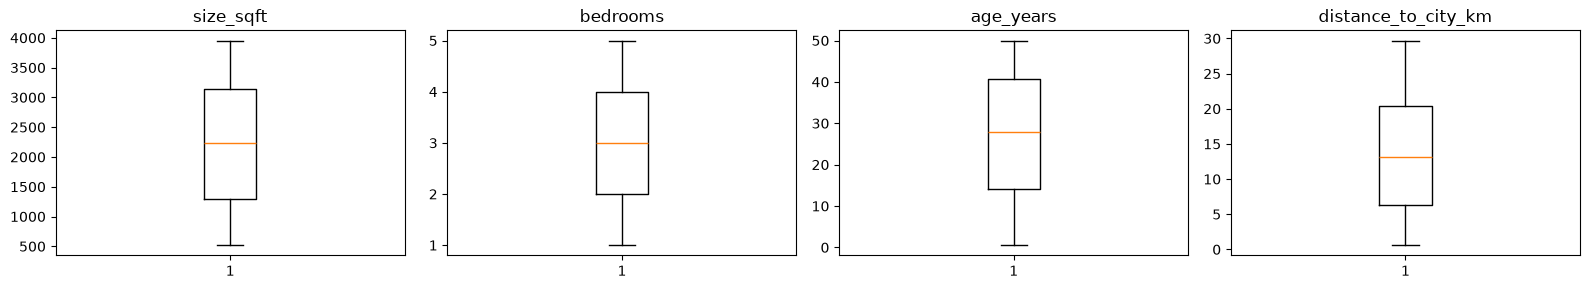

size_sqft: min=519.3, max=3954.1, range=3434.8
bedrooms: min=1.0, max=5.0, range=4.0
age_years: min=0.5, max=50.0, range=49.4
distance_to_city_km: min=0.6, max=29.7, range=29.1


In [2]:
feature_names = ["size_sqft", "bedrooms", "age_years", "distance_to_city_km"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, name in enumerate(feature_names):
    axes[i].boxplot(X[:, i])
    axes[i].set_title(name)
plt.tight_layout()
plt.show()

# Print the actual ranges to make the magnitude gap explicit in numbers, not just visuals
for i, name in enumerate(feature_names):
    print(f"{name}: min={X[:, i].min():.1f}, max={X[:, i].max():.1f}, range={X[:, i].max() - X[:, i].min():.1f}")

## 3. Feature scaling — z-score normalization

We rescale each feature so it has mean 0 and standard deviation 1:

$$x_j^{(scaled)} = \frac{x_j - \mu_j}{\sigma_j}$$

where $\mu_j$ is the mean and $\sigma_j$ is the standard deviation of feature $j$,
computed **per column** (each feature scaled independently, since they have
different units and ranges).

We implement this ourselves with NumPy rather than using `sklearn.preprocessing.StandardScaler`,
since the goal here is to understand the mechanics, not just call a library.

In [3]:
def zscore_normalize(X):
    """
    Normalize each feature (column) of X to zero mean and unit variance.

    Args:
        X (ndarray (m, n)): input features, m examples, n features

    Returns:
        X_norm (ndarray (m, n)): normalized features
        mu (ndarray (n,)): mean of each feature (needed later to normalize new data)
        sigma (ndarray (n,)): std dev of each feature (needed later too)
    """
    mu = np.mean(X, axis=0)      # mean of each column -> shape (n,)
    sigma = np.std(X, axis=0)    # std dev of each column -> shape (n,)
    X_norm = (X - mu) / sigma    # broadcasting: (m,n) - (n,) works column-wise
    return X_norm, mu, sigma

X_norm, mu, sigma = zscore_normalize(X)

print("mu:", mu)
print("sigma:", sigma)
print("\nBefore scaling - first row:", X[0])
print("After scaling  - first row:", X_norm[0])

# Sanity check: every scaled feature should now have mean ~0, std ~1
print("\nMean of each scaled feature (should be ~0):", np.mean(X_norm, axis=0))
print("Std of each scaled feature (should be ~1):", np.std(X_norm, axis=0))

mu: [2194.02181643    3.035        26.65148519   13.86490784]
sigma: [1029.53647562    1.43658449   15.58128245    8.32156046]

Before scaling - first row: [1810.89041597    4.           48.05952819   11.76732135]
After scaling  - first row: [-0.37213971  0.67173216  1.37395898 -0.25206648]

Mean of each scaled feature (should be ~0): [ 1.42108547e-15 -2.99760217e-17 -5.37070388e-17  3.18634008e-16]
Std of each scaled feature (should be ~1): [1. 1. 1. 1.]


## 4. Cost function (vectorized)

For multiple linear regression, the model is:

$$f_{w,b}(x) = w_1x_1 + w_2x_2 + \dots + w_nx_n + b = \vec{w} \cdot \vec{x} + b$$

And the squared error cost over all $m$ examples is:

$$J(\vec{w}, b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2$$

We compute this **vectorized** — as matrix operations over the whole dataset at once,
rather than looping over each of the $m$ examples in Python. This isn't just a style
preference: on real datasets, a Python `for` loop over thousands of rows is dramatically
slower than the equivalent NumPy operation, which runs in optimized C under the hood.

In [ ]:
def compute_cost(X, y, w, b):
    """
    Compute the squared error cost for linear regression, vectorized.

    Args:
        X (ndarray (m,n)): m examples, n features
        y (ndarray (m,)): target values
        w (ndarray (n,)): model weights
        b (scalar): model bias

    Returns:
        cost (scalar): the mean squared error cost
    """
    m = X.shape[0]
    predictions = X @ w + b              # shape (m,) - predicts all m examples at once
    errors = predictions - y             # shape (m,)
    cost = np.sum(errors ** 2) / (2 * m) 
    return cost

# Sanity check with arbitrary weights (not yet trained - just testing the function works)
w_test = np.zeros(4)
b_test = 0.0
initial_cost = compute_cost(X_norm, y, w_test, b_test)
print("Cost with w=0, b=0:", initial_cost)

Cost with w=0, b=0: 92581195405.1087


## 5. Gradient computation (vectorized)

To minimize $J(\vec{w}, b)$, we need its partial derivatives:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)x_j^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)$$

In vectorized form, the gradient with respect to $\vec{w}$ (all $n$ partial derivatives
at once) is simply $X^T \cdot \text{errors}$ — the transpose of $X$ dotted with the
error vector, scaled by $1/m$.

In [5]:
def compute_gradient(X, y, w, b):
    """
    Compute the gradient of the cost function w.r.t. w and b, vectorized.

    Args:
        X (ndarray (m,n)): m examples, n features
        y (ndarray (m,)): target values
        w (ndarray (n,)): model weights
        b (scalar): model bias

    Returns:
        dj_dw (ndarray (n,)): gradient w.r.t. each weight
        dj_db (scalar): gradient w.r.t. bias
    """
    m = X.shape[0]
    predictions = X @ w + b
    errors = predictions - y                  # shape (m,)

    dj_dw = (X.T @ errors) / m                # X.T is (n,m), errors is (m,) -> result (n,)
    dj_db = np.sum(errors) / m                # scalar

    return dj_dw, dj_db

# Sanity check with the same test weights as before
dj_dw_test, dj_db_test = compute_gradient(X_norm, y, w_test, b_test)
print("dj_dw:", dj_dw_test)
print("dj_db:", dj_db_test)

dj_dw: [-149597.26549159  -11698.6905822    14194.28728857  -15673.61976235]
dj_db: -402005.5136492963


## 6. Gradient descent

Now we combine `compute_cost` and `compute_gradient` into the actual training loop:
repeatedly compute the gradient, take a small step in the opposite direction (scaled
by learning rate $\alpha$), and repeat. We track cost at each iteration so we can
verify convergence visually afterward.

In [11]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters, verbose=True):
    """
    Perform batch gradient descent to learn w, b.

    Args:
        X (ndarray (m,n)): training features
        y (ndarray (m,)): target values
        w_init (ndarray (n,)): initial weights
        b_init (scalar): initial bias
        alpha (float): learning rate
        num_iters (int): number of iterations to run

    Returns:
        w (ndarray (n,)): learned weights
        b (scalar): learned bias
        J_history (list): cost at each iteration, for plotting convergence
    """
    w = w_init.copy()   # copy - don't mutate the caller's original array
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        J_history.append(compute_cost(X, y, w, b))

        # Print progress occasionally so we can watch it working without flooding output
        if verbose and i % (num_iters // 10) == 0:
            print(f"Iteration {i:5}: Cost {J_history[-1]:.2f}")

    return w, b, J_history

# Train on the NORMALIZED features
w_init = np.zeros(4)
b_init = 0.0
alpha = 0.1
num_iters = 1000

w_final, b_final, J_history = gradient_descent(X_norm, y, w_init, b_init, alpha, num_iters)

print("\nFinal w:", w_final)
print("Final b:", b_final)
print("True w was:", w_true)
print("True b was:", b_true)

Iteration     0: Cost 75049597537.28
Iteration   100: Cost 111467501.67
Iteration   200: Cost 111466813.53
Iteration   300: Cost 111466813.53
Iteration   400: Cost 111466813.53
Iteration   500: Cost 111466813.53
Iteration   600: Cost 111466813.53
Iteration   700: Cost 111466813.53
Iteration   800: Cost 111466813.53
Iteration   900: Cost 111466813.53

Final w: [154000.35535116  28255.80175584 -10325.68363409 -11747.73097637]
Final b: 402005.51364929584
True w was: [  150 20000  -800 -1200]
True b was: 50000


## 7. Converting normalized weights back to original feature units

We trained on scaled features, so `w_final` represents "price change per 1 standard
deviation of the scaled feature," not "price change per square foot." To compare
against our known ground truth (`w_true`), we need to convert back:

$$w_{original,j} = \frac{w_{scaled,j}}{\sigma_j}, \qquad b_{original} = b_{scaled} - \sum_j w_{original,j} \cdot \mu_j$$

This isn't just bookkeeping — it's the same math you'd need in any real deployment
where predictions must be interpretable in real-world units.

In [7]:
w_original = w_final / sigma
b_original = b_final - np.sum(w_original * mu)

print("Learned w (original units):", w_original)
print("True w:                    ", w_true)
print("\nLearned b (original units):", b_original)
print("True b:                    ", b_true)

Learned w (original units): [  149.58222365 19668.73645885  -662.69793031 -1411.72211984]
True w:                     [  150 20000  -800 -1200]

Learned b (original units): 51359.517626339046
True b:                     50000


## 8. Visualizing convergence

A cost-vs-iteration plot is the standard way to sanity-check gradient descent. We
expect a steep drop early on, then a flattening plateau as it converges — matching
what we saw numerically in the printed iterations above.

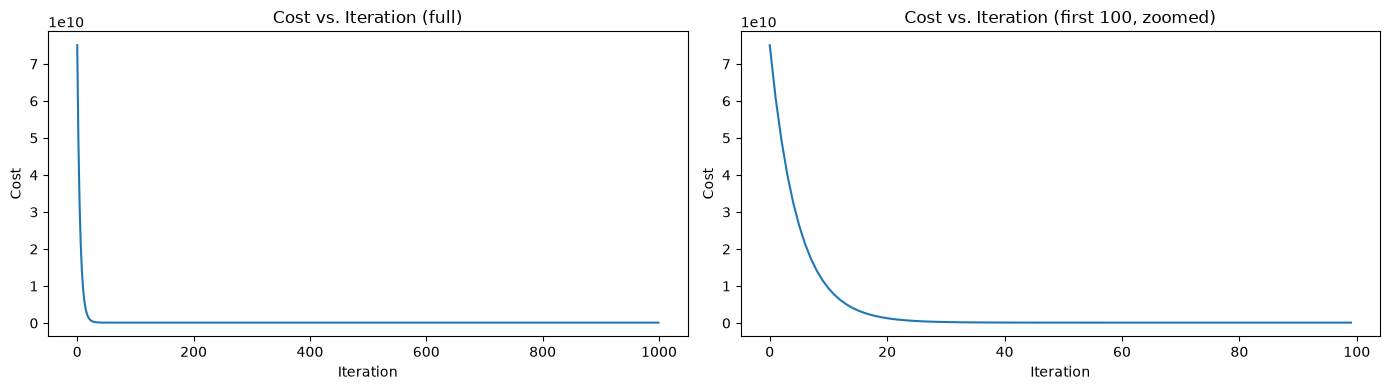

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full curve
axes[0].plot(J_history)
axes[0].set_title("Cost vs. Iteration (full)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost")

# Zoomed into the first 100 iterations, where the interesting action happens
axes[1].plot(J_history[:100])
axes[1].set_title("Cost vs. Iteration (first 100, zoomed)")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Cost")

plt.tight_layout()
plt.show()

## 9. Choosing the learning rate

We'll run gradient descent with several different values of $\alpha$ and compare
their cost curves directly. This shows concretely what "too small," "too large,"
and "just right" actually look like — not just as a rule of thumb, but as a plot.

In [14]:
learning_rates = [0.001, 0.01, 0.1, 1.0, 3.0]
histories = {}

for alpha_test in learning_rates:
    w_init = np.zeros(4)
    b_init = 0.0
    w_temp, b_temp, J_hist = gradient_descent(X_norm, y, w_init, b_init, alpha_test, 200, verbose=False)
    histories[alpha_test] = J_hist
    print(f"alpha={alpha_test}: final cost = {J_hist[-1]:.2f}")

# Suppress the per-run iteration printing by temporarily removing it, OR just let it print - either is fine to observe

alpha=0.001: final cost = 62157491263.14
alpha=0.01: final cost = 1865579380.99
alpha=0.1: final cost = 111466813.53
alpha=1.0: final cost = 111466813.53
alpha=3.0: final cost = 1066587915479009748396066954119432395929728941184216267706803579050054019966232868304806038695361808602388301972072270656793758059684588970128718788727112069931625086976.00


## 10. Comparing learning rates visually

Plotting all five cost curves together makes the effect of $\alpha$ immediate:
too small barely moves, well-chosen values converge quickly and stay flat,
and too large diverges — cost increasing instead of decreasing.

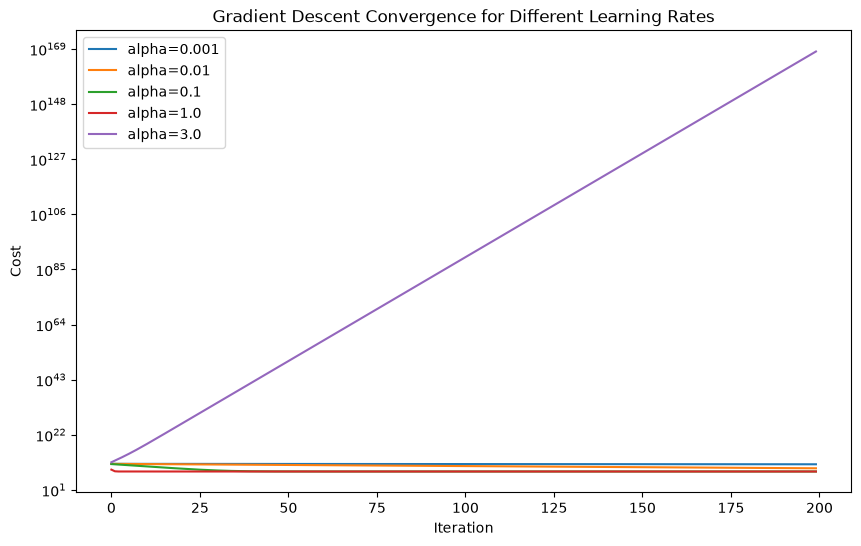

In [16]:
plt.figure(figsize=(10, 6))
for alpha_test, J_hist in histories.items():
    plt.plot(J_hist, label=f"alpha={alpha_test}")

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence for Different Learning Rates")
plt.legend()
plt.yscale("log")  # log scale is essential here - alpha=3.0's cost will otherwise squash everything else flat
plt.show()

## 11. Feature engineering

Feature engineering means creating new input features by combining existing ones,
based on domain reasoning about what might actually drive the target variable.
It's not about adding random combinations — each new feature should have a
plausible reason to matter.

Here, we create `rooms_density = size_sqft / bedrooms` — roughly "square feet per
bedroom," a proxy for how spacious each room feels. This is a genuinely different
signal from either `size_sqft` or `bedrooms` alone: a 3000 sqft house with 5 bedrooms
feels different from a 3000 sqft house with 2 bedrooms, even though `size_sqft` is
identical in both.

In [17]:
# New engineered feature: square feet per bedroom
rooms_density = size_sqft / bedrooms

# Add it as a 5th column to our feature matrix
X_engineered = np.column_stack([size_sqft, bedrooms, age_years, distance_to_city_km, rooms_density])

print("New X shape:", X_engineered.shape)
print("First row:", X_engineered[0])

# Re-scale (new feature has its own range, needs its own mu/sigma)
X_engineered_norm, mu_eng, sigma_eng = zscore_normalize(X_engineered)

# Retrain
w_init = np.zeros(5)
b_init = 0.0
w_eng, b_eng, J_hist_eng = gradient_descent(X_engineered_norm, y, w_init, b_init, alpha=0.1, num_iters=1000, verbose=False)

print("\nFinal cost WITHOUT engineered feature:", J_history[-1])
print("Final cost WITH engineered feature:   ", J_hist_eng[-1])

New X shape: (200, 5)
First row: [1810.89041597    4.           48.05952819   11.76732135  452.72260399]

Final cost WITHOUT engineered feature: 111466813.53233272
Final cost WITH engineered feature:    111211145.66438721


## 12. Polynomial regression

Polynomial regression fits nonlinear relationships by adding powers of existing
features as new columns — e.g., `size_sqft^2` — while still using linear regression
machinery underneath (it's linear in the *weights*, even though the relationship to
the original feature is now curved).

We test this on `age_years`, since houses often show a nonlinear relationship with
age in reality (e.g., value might drop fast early on, then plateau) — though as with
feature engineering above, we should expect this to help only if such a nonlinear
pattern genuinely exists in our data.

In [18]:
# Add age_years squared as a new feature
age_squared = age_years ** 2

X_poly = np.column_stack([size_sqft, bedrooms, age_years, distance_to_city_km, age_squared])

X_poly_norm, mu_poly, sigma_poly = zscore_normalize(X_poly)

w_init = np.zeros(5)
b_init = 0.0
w_poly, b_poly, J_hist_poly = gradient_descent(X_poly_norm, y, w_init, b_init, alpha=0.1, num_iters=1000, verbose=False)

print("Final cost WITHOUT polynomial term:", J_history[-1])
print("Final cost WITH age_years^2 term:  ", J_hist_poly[-1])

Final cost WITHOUT polynomial term: 111466813.53233272
Final cost WITH age_years^2 term:   110971782.8985132


## 13. Final model evaluation — predicted vs. actual

As a final sanity check, we plot predicted prices against actual prices for our
best model (the original 4-feature model, since the engineered/polynomial features
didn't meaningfully help). A well-fit model should show points clustering tightly
around the diagonal line y = x — perfect predictions would fall exactly on it.

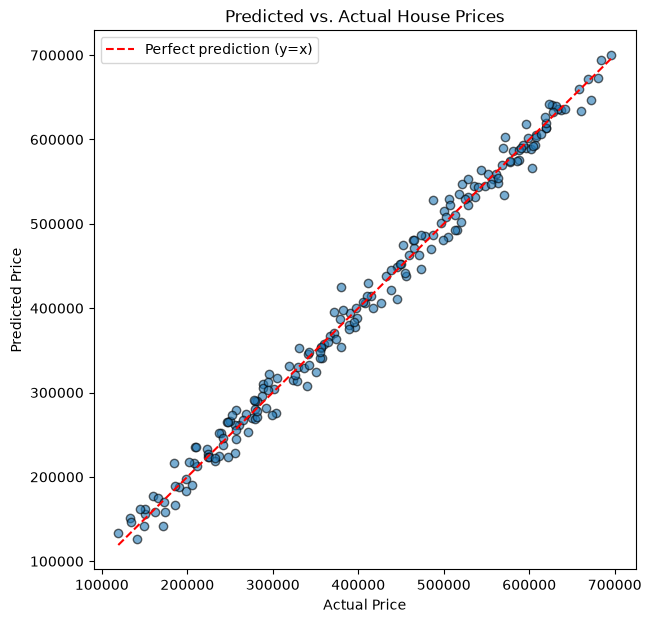

Mean Absolute Error: $11,824.64


In [19]:
predictions_final = X_norm @ w_final + b_final

plt.figure(figsize=(7, 7))
plt.scatter(y, predictions_final, alpha=0.6, edgecolor='k')

# Diagonal reference line: perfect predictions would fall exactly on this line
min_val, max_val = y.min(), y.max()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction (y=x)')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs. Actual House Prices")
plt.legend()
plt.show()

# Also report mean absolute error in dollars - more interpretable than raw cost
mae = np.mean(np.abs(predictions_final - y))
print(f"Mean Absolute Error: ${mae:,.2f}")